
# Kaart: Stedelijkheid per gemeente — **OFFLINE harmonized+**

Deze versie voegt **gerichte aliasregels** toe voor Drenthe (Aa en Hunze, Borger‑Odoorn, Tynaarlo, Noordenveld, Midden‑Drenthe)
en verlaagt de fuzzy drempel voor eventuele restgevallen. Het doel is die laatste **witte plek bij Gieten** te vullen.


In [7]:

# === Instellingen ===
CSV_PATH = "Gebieden_in_Nederland_2022.csv"
GPKG_PATH = "BestuurlijkeGebieden_2025.gpkg"
OUTPUT_HTML = "map_stedelijkheid.html"
OUTPUT_PNG = "map_stedelijkheid.png"
MATCH_THRESHOLD = 85  # iets lager dan eerst


## 1) CSV inlezen en mapping bepalen

In [8]:

import pandas as pd, re

df = pd.read_csv(
    CSV_PATH,
    sep=';',
    header=None,
    skiprows=5,
    names=[df.columns[0] if 'df' in globals() and hasattr(df, 'columns') else 'Regio',
           'Code', 'Omschrijving', 'Per_km2'],
    quotechar='"',
    engine='python'
)
df = df.rename(columns={df.columns[0]: "naam_gemeente",
                        df.columns[1]: "code",
                        df.columns[2]: "omschrijving"})
df["STED"] = pd.to_numeric(df["code"], errors="coerce").astype("Int64")
def pretty_label(s: str) -> str:
    t = s.strip()
    t = t.replace("Zeersterkstedelijk", "Zeer sterk stedelijk")
    t = t.replace("Sterkstedelijk", "Sterk stedelijk")
    t = t.replace("Matigstedelijk", "Matig stedelijk")
    t = t.replace("Weinigstedelijk", "Weinig stedelijk")
    t = t.replace("Nietstedelijk", "Niet stedelijk")
    t = re.sub(r"(\w)(stedelijk)", r"\1 stedelijk", t, flags=re.IGNORECASE)
    return t[0].upper() + t[1:] if t else t
df["STED_LABEL"] = df["omschrijving"].astype(str).map(pretty_label)
code_label = (df.dropna(subset=["STED"])[["STED","STED_LABEL"]].drop_duplicates(subset=["STED"]).sort_values("STED"))
mapping = dict(zip(code_label["STED"].astype(int), code_label["STED_LABEL"]))
sdf = df[["naam_gemeente","STED","STED_LABEL"]].dropna(subset=["STED"]).copy()
print("Mapping:", mapping)


Mapping: {1: 'Zeer sterk stedelijk', 2: 'Sterk stedelijk', 3: 'Matig stedelijk', 4: 'Weinig stedelijk', 5: 'Niet stedelijk'}


## 2) Messy code to match province names between the stedelijkheid file and the map of provinces
GeoPackage + normalisatie + fusies + gerichte aliasing + fuzzy

In [9]:

import geopandas as gpd, fiona, numpy as np, re
from unidecode import unidecode
import pandas as pd

layers = fiona.listlayers(GPKG_PATH)
gemeente_layer = None
for lyr in layers:
    if "gemeente" in lyr.lower():
        gemeente_layer = lyr; break
if gemeente_layer is None:
    raise RuntimeError("Geen laag met 'gemeente' gevonden. Lagen: " + str(layers))
gdf_gem = gpd.read_file(GPKG_PATH, layer=gemeente_layer)

cols = {c.lower(): c for c in gdf_gem.columns}
naam_col = cols.get("naam") or cols.get("gemeentenaam") or cols.get("statnaam") or list(gdf_gem.columns)[0]

def normalize_name(s: str) -> str:
    s = str(s)
    s = re.sub(r"\(.*?\)", "", s)
    s = s.replace("&", " en ")
    s = s.replace("-", " ")
    s = s.replace("’","'").replace("`","'")
    s = unidecode(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

gdf_gem["__naam_norm"] = gdf_gem[naam_col].map(normalize_name)
sdf["__naam_norm"] = sdf["naam_gemeente"].map(normalize_name)

# Fusies
fusions = {"voorne aan zee": ["hellevoetsluis","brielle","westvoorne"]}

# Gerichte aliasing voor Drenthe en varianten
aliases_direct = {
    "aa en hunze": ["aa en hunze", "gieten"],  # gieten is kernnaam; map naar gemeentenaam
    "borger odoorn": ["borger-odoorn","borgerodoorn","borger  odoorn"],
    "tynaarlo": ["tynaarlo","tyn aar lo"],  # just in case
    "noordenveld": ["noordenveld"],
    "midden drenthe": ["midden-drenthe","midden  drenthe"],
}
# Verwissel mapping: bron→doel
alias_map = {}
for target, sources in aliases_direct.items():
    for s in sources:
        alias_map[normalize_name(s)] = target

# Pas aliases toe op CSV zijde
sdf["__naam_norm"] = sdf["__naam_norm"].map(lambda x: alias_map.get(x, x))

# Directe merge
gdf = gdf_gem.merge(sdf[["__naam_norm","STED","STED_LABEL"]], on="__naam_norm", how="left")

# Fusieoplossing
for new_name, old_list in fusions.items():
    idx = gdf["__naam_norm"] == new_name
    if idx.any() and gdf.loc[idx, "STED"].isna().any():
        vals = sdf[sdf["__naam_norm"].isin(old_list)]["STED"].dropna().astype(int).tolist()
        if vals:
            gdf.loc[idx, "STED"] = int(round(float(np.mean(vals))))
            gdf.loc[idx, "STED_LABEL"] = gdf.loc[idx, "STED"].map(mapping)

# Fuzzy voor resterende missers
unmatched = gdf[gdf["STED"].isna()][["__naam_norm"]].drop_duplicates()["__naam_norm"].tolist()
csv_names = sdf["__naam_norm"].drop_duplicates().tolist()

try:
    from rapidfuzz import process, fuzz
    def best_match(name):
        cand, score, _ = process.extractOne(name, csv_names, scorer=fuzz.WRatio)
        return cand, score
except Exception:
    import difflib
    def best_match(name):
        cand = difflib.get_close_matches(name, csv_names, n=1, cutoff=0.0)
        cand = cand[0] if cand else None
        import difflib as dl
        score = int(100 * dl.SequenceMatcher(None, name, cand).ratio()) if cand else 0
        return cand, score

fixes = {}
for name in unmatched:
    cand, score = best_match(name)
    if cand and score >= MATCH_THRESHOLD:
        fixes[name] = (cand, score)

if fixes:
    fix_df = pd.DataFrame([{"target":k, "source":v[0], "score":v[1]} for k,v in fixes.items()])
    src_map = sdf.set_index("__naam_norm")[["STED","STED_LABEL"]]
    for _, row in fix_df.iterrows():
        target = row["target"]; src = row["source"]
        if src in src_map.index:
            sted = src_map.loc[src, "STED"]
            labl = src_map.loc[src, "STED_LABEL"]
            gdf.loc[gdf["__naam_norm"]==target, "STED"] = sted
            gdf.loc[gdf["__naam_norm"]==target, "STED_LABEL"] = labl

print("Nog zonder match:", int(gdf["STED"].isna().sum()))


Nog zonder match: 0


In [10]:

# --- Fast coastline clip: prefer Natural Earth, else OSM subset + simplify ---
import os, glob, geopandas as gpd

# Tunables
BBOX_PAD_DEG = 0.3   # bbox pad in degrees (around NL)
SIMPLIFY_M   = 80.0  # simplify tolerance in meters (RD New)
OPS_CRS      = 28992 # EPSG:28992 (RD New) for fast geometry ops

# Compute NL bbox in 4326
_g_wgs = gdf_gem.to_crs(4326)
minx, miny, maxx, maxy = _g_wgs.total_bounds
bbox = (minx - BBOX_PAD_DEG, miny - BBOX_PAD_DEG, maxx + BBOX_PAD_DEG, maxy + BBOX_PAD_DEG)

# 1) Try Natural Earth "Land" first (very light & fast)
NE_PATH = "land-polygons-complete-4326/land_polygons.shp"

land_gdf = gpd.read_file(NE_PATH, bbox=bbox)  # tiny subset

if land_gdf is not None and not land_gdf.empty:
    # Reproject to RD New for fast/accurate ops in meters
    orig_crs = gdf_gem.crs
    g_ops    = gdf_gem.to_crs(OPS_CRS)
    land_ops = land_gdf.to_crs(OPS_CRS)

    # Optional clean + simplify (huge speed gain on OSM land)
    land_ops["geometry"] = land_ops.geometry.buffer(0)
    land_ops["geometry"] = land_ops.geometry.simplify(SIMPLIFY_M, preserve_topology=True)

    # Dissolve to a single land mask
    try:
        land_mask = land_ops.unary_union
    except Exception:
        land_mask = land_ops.dissolve().geometry.unary_union

    # Intersect and bring back to original CRS
    g_ops["geometry"] = g_ops.geometry.intersection(land_mask)
    g_ops = g_ops[~g_ops.geometry.is_empty & g_ops.geometry.notnull()].copy()
    gdf_gem = g_ops.to_crs(orig_crs)
    print("✔ Clipped to land (fast): bbox pad=%.1f°, simplify=%.1fm" % (BBOX_PAD_DEG, SIMPLIFY_M))
else:
    print("ℹ Land subset empty or missing; clip skipped.")


C:\Users\DakIoan\AppData\Local\Temp\ipykernel_6372\2849845102.py:31: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  land_mask = land_ops.unary_union


✔ Clipped to land (fast): bbox pad=0.3°, simplify=80.0m


## 3) Kaarten genereren (Folium + PNG) — jet_r en woordlegenda

In [11]:

# --- FINAL-STAGE CLIP (FULL): land + lakes/estuaries + **coarse rivers** + gap-bridging ---
# Keeps the proven estuary behavior; only rivers are coarsened.
import os, glob, geopandas as gpd, pandas as pd

# Parameters (coarse & robust)
BBOX_PAD_DEG       = 0.3
OPS_CRS            = 28992   # RD New
SIMPLIFY_LAND_M    = 80.0
SIMPLIFY_WATER_M   = 120.0
SIMPLIFY_RIVER_M   = 180.0
RIVER_BUFFER_M     = 220.0
MIN_WATER_AREA_KM2 = 3.0
MIN_RIVER_LEN_KM   = 20.0
UNION_GRID_M       = 1.5
CLEAN_BUF_M        = 1.2
BRIDGE_M           = 220.0

# Whitelists for rivers (by class / name) — don't change polygon behavior
MAJOR_FCLASSES_LINE = {"river", "canal"}
MAJOR_RIVER_NAME_SNIPPETS = [
    "rijn","waal","maas","schelde","ijssel","lek","neder-rijn","merwede","oude maas",
    "nieuwe maas","haringvliet","hollands diep","oosterschelde","westerschelde",
    "amsterdam-rijnkanaal","noord","boven merwede","bergsche maas","ketelmeer"
]

def _col(df, *cands):
    m = {c.lower(): c for c in df.columns}
    for c in cands:
        if c in m: return m[c]
    return None

def _make_valid_series(geos):
    try:
        from shapely import make_valid as _make_valid
        return geos.apply(_make_valid)
    except Exception:
        return geos.buffer(0)

def _clean_series(geos, simplify_m):
    g = _make_valid_series(geos)
    g = g.buffer(CLEAN_BUF_M, cap_style=3, join_style=2)
    g = g.simplify(simplify_m, preserve_topology=True)
    g = g.buffer(-CLEAN_BUF_M, cap_style=3, join_style=2)
    return g

def _chunk_union(arr, grid_size=UNION_GRID_M, chunk=400):
    try:
        from shapely import union_all as _ua
        parts = []
        for i in range(0, len(arr), chunk):
            parts.append(_ua(arr[i:i+chunk], grid_size=grid_size))
        return _ua(parts, grid_size=grid_size)
    except Exception:
        try:
            from shapely import coverage_union_all as _cov
            return _cov(arr)
        except Exception:
            from shapely import union_all as _ua2
            return _ua2(arr)

def _mask_from_gdf(gdf, simplify_m):
    if gdf is None or gdf.empty: return None
    g = _clean_series(gdf.geometry, simplify_m)
    arr = [geom for geom in g.values if geom and not geom.is_empty]
    if not arr: return None
    return _chunk_union(arr)

if 'gdf' in globals():
    # 1) BBOX in WGS84 from final gdf
    _g_wgs = gdf.to_crs(4326)
    minx, miny, maxx, maxy = _g_wgs.total_bounds
    bbox = (minx - BBOX_PAD_DEG, miny - BBOX_PAD_DEG, maxx + BBOX_PAD_DEG, maxy + BBOX_PAD_DEG)

    # 2) LAND (NE preferred; else OSM land polygons
    orig_crs = gdf.crs
    g_ops    = gdf.to_crs(OPS_CRS)
    land_ops = land_gdf.to_crs(OPS_CRS)
    land_mask = _mask_from_gdf(land_ops, SIMPLIFY_LAND_M)

    # Intersect municipalities with land first (coastline)
    g_ops["geometry"] = _make_valid_series(g_ops.geometry).intersection(land_mask)

    # 3) WATER POLYGONS (estuaries/lakes) — keep as before; just filter tiny slivers
    water_polys = []

    # NE lakes (light, good coverage)
    water_polys.append(gpd.read_file("ne_10m_lakes/ne_10m_lakes.shp", bbox=bbox))

    # Province water AREAS (true polygons for estuaries/riverbanks)
    for folder in ["zeeland", "zuid-holland", "noord-brabant"]:
        shp = os.path.join(folder, "gis_osm_water_a_free_1.shp")
        if os.path.exists(shp):
            water_polys.append(gpd.read_file(shp, bbox=bbox))

    water_poly_mask = None
    if water_polys:
        poly_ops = [w.to_crs(OPS_CRS) for w in water_polys if w is not None and not w.empty]
        if poly_ops:
            poly_ops = [w.assign(geometry=_make_valid_series(w.geometry)) for w in poly_ops]
            merged = gpd.GeoDataFrame(pd.concat(poly_ops, ignore_index=True), geometry="geometry", crs=OPS_CRS)
            # Drop tiny polygons (< MIN_WATER_AREA_KM2)
            merged["__area"] = merged.geometry.area
            merged = merged[merged["__area"] >= MIN_WATER_AREA_KM2 * 1_000_000].copy()
            merged.drop(columns=["__area"], inplace=True, errors="ignore")
            water_poly_mask = _mask_from_gdf(merged, SIMPLIFY_WATER_M)

    # 4) WATERWAYS (lines) — **coarse** rivers only
    line_parts = []
    for folder in ["zeeland", "zuid-holland", "noord-brabant"]:
        shp = os.path.join(folder, "gis_osm_waterways_free_1.shp")
        if os.path.exists(shp):
            line_parts.append(gpd.read_file(shp, bbox=bbox))
    river_mask = None
    if line_parts:
        ww = gpd.GeoDataFrame(pd.concat(line_parts, ignore_index=True), crs=line_parts[0].crs)
        fclass_col = _col(ww, "fclass","class","waterway","type")
        name_col   = _col(ww, "name","namn","naam")

        if fclass_col:
            ww = ww[ww[fclass_col].str.lower().isin(MAJOR_FCLASSES_LINE)]
        if name_col:
            ww["__keep_name"] = ww[name_col].str.lower().fillna("").apply(lambda s: any(sn in s for sn in MAJOR_RIVER_NAME_SNIPPETS))
        else:
            ww["__keep_name"] = False

        ww_ops = ww.to_crs(OPS_CRS)
        ww_ops["__len_km"] = ww_ops.geometry.length / 1000.0
        ww_ops = ww_ops[(ww_ops["__keep_name"]) | (ww_ops["__len_km"] >= MIN_RIVER_LEN_KM)].copy()

        ww_ops["geometry"] = _make_valid_series(ww_ops.geometry.buffer(RIVER_BUFFER_M))
        ww_ops["geometry"] = ww_ops.geometry.simplify(SIMPLIFY_RIVER_M, preserve_topology=True)
        ww_ops["geometry"] = _make_valid_series(ww_ops.geometry)

        river_mask = _mask_from_gdf(ww_ops, SIMPLIFY_RIVER_M)

    # 5) Combine water masks (estuaries + rivers) and subtract *inland* water
    water_mask = water_poly_mask.union(river_mask) if (water_poly_mask and river_mask) else (water_poly_mask or river_mask)

    if water_mask:
        # Restrict to inland water only
        water_inland = water_mask.intersection(land_mask)
        # Bridge tiny gaps at river mouths inside land to ensure connection
        try:
            water_inland = water_inland.buffer(BRIDGE_M).buffer(-BRIDGE_M)
        except Exception:
            pass
        g_ops["geometry"] = _make_valid_series(g_ops.geometry).difference(water_inland.buffer(0))

    # 6) Clean up and return to original CRS
    g_ops = g_ops[~g_ops.geometry.is_empty & g_ops.geometry.notnull()].copy()
    gdf = g_ops.to_crs(orig_crs)
    print("✔ Final FULL clip applied (land + lakes/estuaries + coarse rivers).")



✔ Final FULL clip applied (land + lakes/estuaries + coarse rivers).


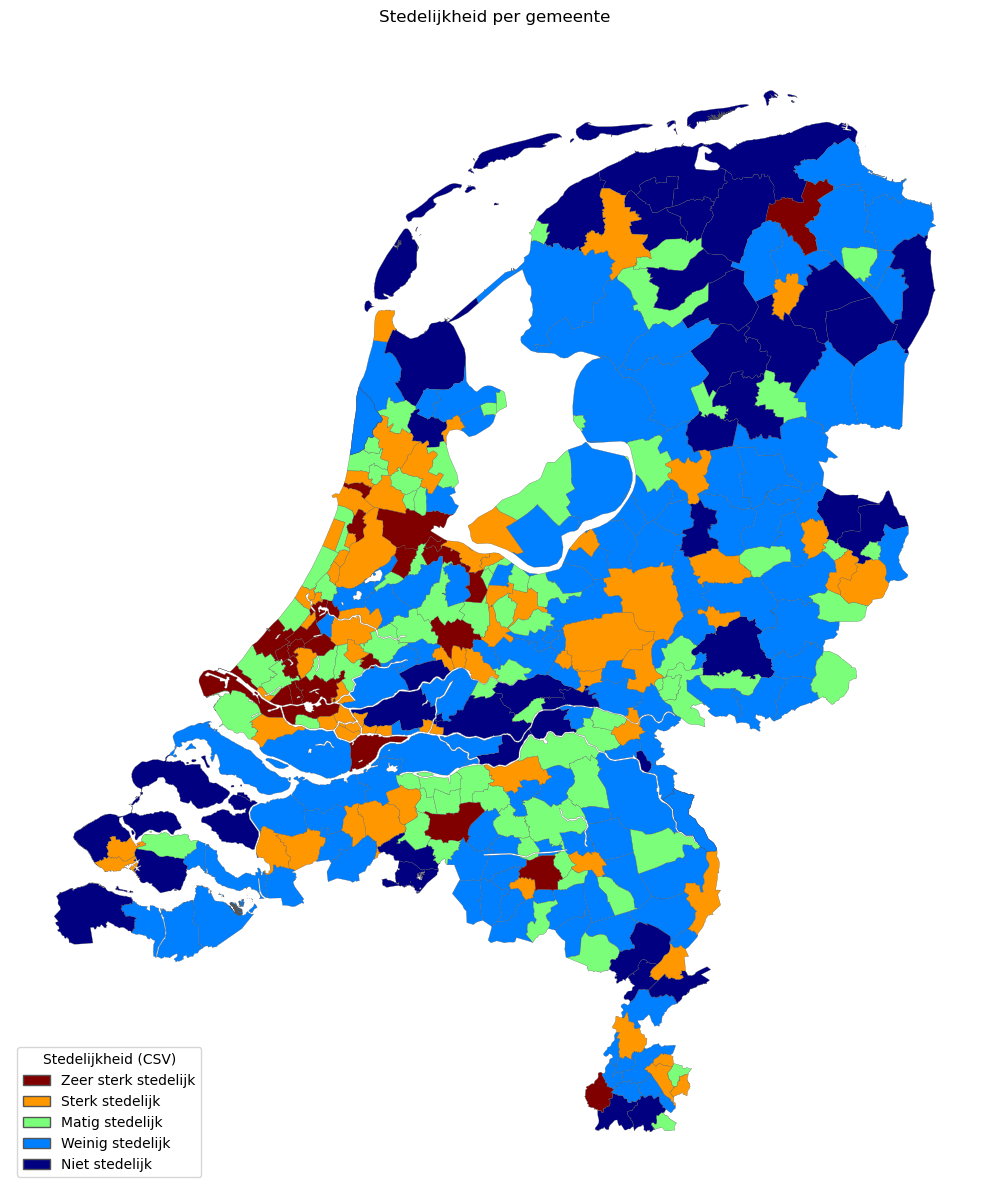

In [12]:

import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.patches import Patch

def plot_stedelijkheid(gdf, mapping, output_png, cmap_name="jet_r"):
    # Sorted unique codes (ensure int for safety/consistency)
    codes = sorted(int(k) for k in mapping.keys())
    n = len(codes)

    cmap = plt.get_cmap(cmap_name, n)
    color_by_code = {code: cmap(i) for i, code in enumerate(codes)}

    # Plot
    fig, ax = plt.subplots(figsize=(10, 12))
    gdf.plot(
        ax=ax,
        column="STED",
        cmap=cmap,
        linewidth=0.2,
        edgecolor="#555",
        legend=False,
        vmin=min(codes),
        vmax=max(codes),
    )
    ax.set_axis_off()
    ax.set_title("Stedelijkheid per gemeente", pad=12)

    # Legend (one handle per code, matching our discrete colormap assignment)
    handles = [
        Patch(facecolor=color_by_code[code], edgecolor="#555", label=mapping[code])
        for code in codes
    ]
    ax.legend(handles=handles, title="Stedelijkheid (CSV)", loc="lower left", frameon=True)

    plt.tight_layout()
    plt.savefig(output_png, dpi=220, bbox_inches="tight")
    plt.show()

# Example usage:
plot_stedelijkheid(gdf, mapping, OUTPUT_PNG)
